# COSC2779 DL Assignments 1: Introduction to Deep Convolutional Neural Networks

**Name:** Rylemarc Jade Aguinaldo
**Student Number:** s3972876

## Imports and Device Configuration

### Install dependencies and packages

In [1]:
%pip install torch torchvision matplotlib numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Training Utilities

Derived from Weeks 3 & 4 Lab notebooks 

In [2]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item() * y.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total


def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=10, name='Model'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f'  [{name}] Epoch {epoch+1}/{epochs} — '
                  f'Train: {train_loss:.4f} / {train_acc:.4f} | '
                  f'Val: {val_loss:.4f} / {val_acc:.4f}')
    return history


def plot_experiments(results, show_train=True, show_val=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, hist in results.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        if show_train:
            axes[0].plot(epochs, hist['train_loss'], label=f'{name} (Train)', marker='o', markersize=3)
            axes[1].plot(epochs, hist['train_acc'], label=f'{name} (Train)', marker='o', markersize=3)
        if show_val:
            axes[0].plot(epochs, hist['val_loss'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
            axes[1].plot(epochs, hist['val_acc'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
    for ax, ylabel, title in zip(axes, ['Loss', 'Accuracy'], ['Loss', 'Accuracy']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Dataset initialisation

### Load Dataset

In [3]:
import os
import re
import zipfile
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

ZIP_PATH = 'A1_data_2026.zip'
DATA_DIR = './data_resized/data_resized'

# ---- Extract zip file ----
if not os.path.isdir(DATA_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print('Extracted to', DATA_DIR)


class CustomFolderDataset(Dataset):
    def __init__(self, samples, transform=None):
        """
        samples: List of (image_path, class_index) tuples
        """
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, target


def load_dataset(root, class_names):
    actual_root = root
    while True:
        subdirectories = [
            d for d in os.listdir(actual_root) 
            if os.path.isdir(os.path.join(actual_root, d)) and not d.startswith('.')
        ]
        if len(subdirectories) == 1 and (subdirectories[0] not in class_names):
            actual_root = os.path.join(actual_root, subdirectories[0])
        else:
            break

    class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')

    all_samples = []
    class_indices = []
    groups = []

    # Example: S13_allClear_HD_instance1_1.jpg
    # Group 1: Subject (S13)
    # Group 2: Gesture Class (allClear)
    # Group 3: Instance ID (instance1)
    pattern = re.compile(r'^(S\d+)_([a-zA-Z0-9]+)_(?:HD_)?(instance\d+)_\d+', re.IGNORECASE)

    for class_name in class_names:
        class_dir = os.path.join(actual_root, class_name)
        if not os.path.isdir(class_dir):
            continue

        target_idx = class_to_idx[class_name]

        for dirpath, _, filenames in os.walk(class_dir):
            for fname in filenames:
                if fname.lower().endswith(valid_exts):
                    img_path = os.path.join(dirpath, fname)
                    
                    match = pattern.match(fname)
                    if match:
                        subject, gesture, instance = match.groups()
                        # Group key combines Subject + Gesture + Instance (e.g., 'S13_alLClear_instance1')
                        group_key = f"{subject}_{gesture}_{instance}"
                    else:
                        # Fallback if filename format varies slightly
                        group_key = os.path.splitext(fname)[0].rsplit('_', 1)[0]

                    all_samples.append((img_path, target_idx))
                    class_indices.append(target_idx)
                    groups.append(group_key)

    return all_samples, class_indices, groups


Image count: 5295
Instance count: 1059.0


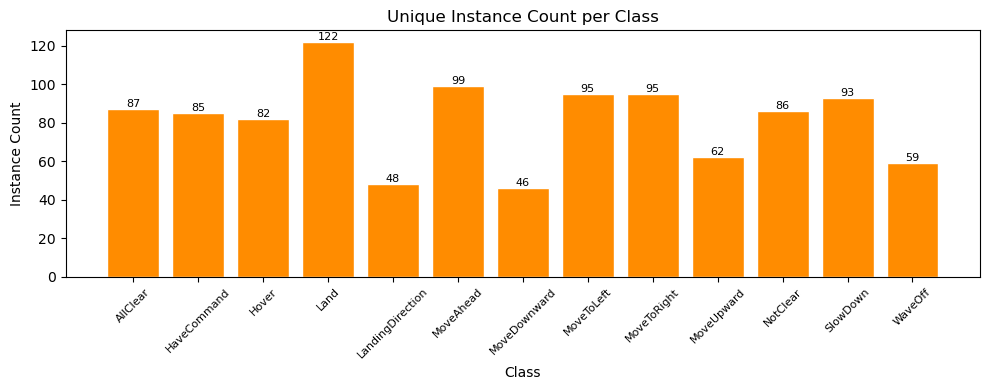

In [13]:
# ---- Class Distribution of Full Dataset ----
CLASS_NAMES = [
    'AllClear', 'HaveCommand', 'Hover', 'Land', 'LandingDirection', 
    'MoveAhead', 'MoveDownward', 'MoveToLeft', 'MoveToRight', 'MoveUpward', 
    'NotClear', 'SlowDown', 'WaveOff'
]

samples, targets, groups = load_dataset(root=DATA_DIR, class_names=CLASS_NAMES)

print(f'Image count: {len(samples)}')
print(f'Instance count: {len(samples) / 5}')

instance_counts_per_class = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_mask = [t == class_idx for t in targets]
    class_instances = len(set(g for g, is_class in zip(groups, class_mask) if is_class))
    instance_counts_per_class[class_name] = class_instances

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(instance_counts_per_class.keys(),
       instance_counts_per_class.values(),
       color='darkorange', edgecolor='white')
ax.set_title('Unique Instance Count per Class')
ax.set_ylabel('Instance Count')
ax.set_xlabel('Class')
ax.tick_params(axis='x', labelsize=8, rotation=45)
for i, (k, v) in enumerate(instance_counts_per_class.items()):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Observations**

- *Land* has the most instances in the dataset with 122
- Four classes have less than 65 instances, with two having less than 50 instances (*Landing Direction*, *MoveDownward*)
- Majority of the classes has an instance count in the 80-100 range

### Split dataset

Before data analysis, the dataset needs to be split into train, validation and test sets to avoid any data leakage. The data will be split into 70% training, and 15% each for the validation and test sets. Since there is a small amount of data available with only 1059 instances, allocating as much data as possible for training the dataset is imperative to ensure that the model is able to capture patterns within the data and generalise well against new data. Instances were used as the metric to quantify the amount of available data instead images as the main requirement of the drone model is to recognise gestures based on instances (multiple frames) rather than individual images (single frame).

Hold-out validation will be used over K-fold as training CNNs are computationally expensive and time-consuming, especially since the amount of time allocated to train the model is relatively low.

To ensure that the 


In [14]:
import numpy as np
from collections import Counter, defaultdict
from sklearn.model_selection import StratifiedGroupKFold
 
def stratified_group_train_val_test_split(all_samples, class_indices, groups, val_size=0.15, test_size=0.15, random_state=42):
    """
    Three-way split (train/val/test), instance-grouped and stratified.
    val_size and test_size are approximate fractions of the total data (by groups).
    """
    all_samples = np.array(all_samples, dtype=object)
    class_indices = np.array(class_indices)
    groups = np.array(groups)
 
    # First split off test set
    n_splits_1 = max(2, round(1 / test_size))
    sgkf1 = StratifiedGroupKFold(n_splits=n_splits_1, shuffle=True, random_state=random_state)
    trainval_idx, test_idx = next(sgkf1.split(all_samples, class_indices, groups))
 
    # Then split remaining trainval into train/val
    remaining_frac = 1 - test_size
    val_frac_of_remaining = val_size / remaining_frac
    n_splits_2 = max(2, round(1 / val_frac_of_remaining))
 
    sgkf2 = StratifiedGroupKFold(n_splits=n_splits_2, shuffle=True, random_state=random_state)
    tv_samples = all_samples[trainval_idx]
    tv_classes = class_indices[trainval_idx]
    tv_groups = groups[trainval_idx]
 
    train_sub_idx, val_sub_idx = next(sgkf2.split(tv_samples, tv_classes, tv_groups))
 
    train_idx = trainval_idx[train_sub_idx]
    val_idx = trainval_idx[val_sub_idx]
 
    train_samples = [tuple(s) for s in all_samples[train_idx]]
    val_samples = [tuple(s) for s in all_samples[val_idx]]
    test_samples = [tuple(s) for s in all_samples[test_idx]]
 
    # ---- Sanity checks: no group leakage across any pair of splits ----
    g_train, g_val, g_test = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
    assert not (g_train & g_val), f"Leakage train/val: {g_train & g_val}"
    assert not (g_train & g_test), f"Leakage train/test: {g_train & g_test}"
    assert not (g_val & g_test), f"Leakage val/test: {g_val & g_test}"
 
    print(f"Train: {len(train_samples)} images across {len(g_train)} instances")
    print(f"Val:   {len(val_samples)} images across {len(g_val)} instances")
    print(f"Test:  {len(test_samples)} images across {len(g_test)} instances")
 
    print("\nClass distribution (train):", Counter(class_indices[train_idx]))
    print("Class distribution (val):  ", Counter(class_indices[val_idx]))
    print("Class distribution (test): ", Counter(class_indices[test_idx]))
 
    return train_samples, val_samples, test_samples, train_idx, val_idx, test_idx

**Transform datasets for normalisation**

In [15]:
# ---- Configuration & Execution ----
CLASS_NAMES = [
    'AllClear', 'HaveCommand', 'Hover', 'Land', 'LandingDirection', 
    'MoveAhead', 'MoveDownward', 'MoveToLeft', 'MoveToRight', 'MoveUpward', 
    'NotClear', 'SlowDown', 'WaveOff'
]

# ---- Load dataset metadata ----
samples, targets, groups = load_dataset(root=DATA_DIR, class_names=CLASS_NAMES)
train_samples, val_samples, test_samples, train_idx, val_idx, test_idx = stratified_group_train_val_test_split(samples, targets, groups)

IMG_SIZE = 128

# Basic transforms (no augmentation yet)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# train_samples, val_samples, test_samples come from your split function
train_dataset = CustomFolderDataset(train_samples, transform=train_transform)
val_dataset   = CustomFolderDataset(val_samples,   transform=val_transform)
test_dataset  = CustomFolderDataset(test_samples,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

Train: 3780 images across 756 instances
Val:   755 images across 151 instances
Test:  760 images across 152 instances

Class distribution (train): Counter({np.int64(3): 430, np.int64(5): 395, np.int64(7): 335, np.int64(11): 335, np.int64(8): 325, np.int64(0): 320, np.int64(10): 315, np.int64(2): 300, np.int64(1): 295, np.int64(9): 220, np.int64(12): 205, np.int64(4): 165, np.int64(6): 140})
Class distribution (val):   Counter({np.int64(3): 95, np.int64(1): 85, np.int64(8): 70, np.int64(7): 65, np.int64(11): 60, np.int64(0): 55, np.int64(9): 55, np.int64(6): 50, np.int64(2): 45, np.int64(4): 45, np.int64(5): 45, np.int64(10): 45, np.int64(12): 40})
Class distribution (test):  Counter({np.int64(3): 85, np.int64(8): 80, np.int64(7): 75, np.int64(10): 70, np.int64(11): 70, np.int64(2): 65, np.int64(0): 60, np.int64(5): 55, np.int64(12): 50, np.int64(1): 45, np.int64(6): 40, np.int64(9): 35, np.int64(4): 30})


## Defining Performance Target

## Exploratory Data Analysis

### Image information

In [ ]:
images, labels = next(iter(train_loader))

print(f'Batch shape: {images.shape}')
print(f'Pixel range: [{images.min():.3f}, {images.max():.3f}]')

### Visualise instances for each class

In [ ]:
# Visualise one instance (5 images) per class
import random

# Rebuild groups aligned with train_dataset.samples (assuming CustomFolderDataset)
# If you kept `groups` from load_dataset, filter it down to the train split instead.
train_paths = [s[0] for s in train_dataset]
train_labels = [s[1] for s in train_dataset]

# Re-derive group key per training sample using the same regex/logic as load_dataset
import re
pattern = re.compile(r'^(S\d+)_([a-zA-Z0-9]+)_(?:HD_)?(instance\d+)_\d+', re.IGNORECASE)

def get_group_key(path):
    fname = os.path.basename(path)
    match = pattern.match(fname)
    if match:
        subject, gesture, instance = match.groups()
        return f"{subject}_{gesture}_{instance}"
    return os.path.splitext(fname)[0].rsplit('_', 1)[0]

train_groups = [get_group_key(p) for p in train_paths]

# For each class, pick one group (instance) at random
class_to_group = {}
for path, label, group in zip(train_paths, train_labels, train_groups):
    if label not in class_to_group:
        candidates = [g for p, l, g in zip(train_paths, train_labels, train_groups) if l == label]
        class_to_group[label] = random.choice(candidates)

num_classes = len(CLASS_NAMES)
fig, axes = plt.subplots(num_classes, 5, figsize=(10, 2 * num_classes))

for row, label in enumerate(sorted(class_to_group.keys())):
    group_key = class_to_group[label]
    # Gather all images belonging to this instance, in order
    instance_paths = sorted([p for p, l, g in zip(train_paths, train_labels, train_groups)
                              if g == group_key])

    for col in range(5):
        ax = axes[row, col] if num_classes > 1 else axes[col]
        if col < len(instance_paths):
            img = Image.open(instance_paths[col]).convert('RGB')
            ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[label], fontsize=10, rotation=0, labelpad=40, va='center')
    axes[row, 0].set_title(f'{CLASS_NAMES[label]} — {group_key}', loc='left', fontsize=9)

plt.suptitle('One Instance (5 images) per Class', fontsize=12)
plt.tight_layout()
plt.show()

### Data distribution - Class and Subject

In [ ]:
# ---- Configuration & Execution ----
CLASS_NAMES = [
    'AllClear', 'HaveCommand', 'Hover', 'Land', 'LandingDirection', 
    'MoveAhead', 'MoveDownward', 'MoveToLeft', 'MoveToRight', 'MoveUpward', 
    'NotClear', 'SlowDown', 'WaveOff'
]

# ---- Show histogram of instance distribution between classes ----
# Get the indices belonging to the train split - Train set only
groups_arr = np.array(groups)
class_indices_arr = np.array(targets)

train_groups = groups_arr[train_idx]
train_targets = class_indices_arr[train_idx]

instance_counts_per_class = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_mask = (train_targets == class_idx)
    class_instances = len(set(train_groups[class_mask]))
    instance_counts_per_class[class_name] = class_instances

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(instance_counts_per_class.keys(),
       instance_counts_per_class.values(),
       color='darkorange', edgecolor='white')
ax.set_title('Unique Instance Count per Class (Train Set)')
ax.set_ylabel('Instance Count')
ax.set_xlabel('Class')
ax.tick_params(axis='x', labelsize=8, rotation=45)
for i, (k, v) in enumerate(instance_counts_per_class.items()):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ---- Show histogram of instance distribution between subjects - train set only ----
groups_arr = np.array(groups)
train_groups = groups_arr[train_idx]

# Extract subject (first part of group_key, e.g. 'S13_allClear_instance1' -> 'S13')
train_subjects = np.array([g.split('_')[0] for g in train_groups])

instance_counts_per_subject = {}
for subject in sorted(set(train_subjects)):
    subject_mask = (train_subjects == subject)
    subject_instances = len(set(train_groups[subject_mask]))
    instance_counts_per_subject[subject] = subject_instances

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(instance_counts_per_subject.keys(),
       instance_counts_per_subject.values(),
       color='forestgreen', edgecolor='white')
ax.set_title('Unique Instance Count per Subject (Train Set)')
ax.set_ylabel('Instance Count')
ax.set_xlabel('Subject')
ax.tick_params(axis='x', labelsize=8, rotation=45)
for i, (k, v) in enumerate(instance_counts_per_subject.items()):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Observation**